##  - Confidence Intervals
##  - Introduction to Cluster Analysis

In [1]:
import numpy as np 
import pandas as pd

In [2]:
file_path = 'titanic_data.csv'
df = pd.read_csv(file_path)

In [3]:
print("The mean age of all passengers is: ", df["Age"].mean())
dfSurvived = df[df["Survived"] == 1]
print("The mean age of all surviving passengers is: ",dfSurvived["Age"].mean())

dfPassed = df[df["Survived"] == 0]
print("The mean age of all non-surviving passengers is: ",dfPassed["Age"].mean())

The mean age of all passengers is:  29.69911764705882
The mean age of all surviving passengers is:  28.343689655172415
The mean age of all non-surviving passengers is:  30.62617924528302


In [4]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [5]:
dfSurvived["Age"].describe()

count    290.000000
mean      28.343690
std       14.950952
min        0.420000
25%       19.000000
50%       28.000000
75%       36.000000
max       80.000000
Name: Age, dtype: float64

## Confidence Intervals
***

We discussed in class how to compute the confidence interval for a single value, the mean. Now, we will compute a Confidence Interval of the difference between two means: the mean age of all the survivors aboard the Titanic alongside the mean age of all those who perished. The mean age of the survivors was less than the mean age of those who pased; let's see if we can gain any insight as to whether this difference in means is statistically significant or not.

**What is a Confidence Interval?**

A confidence interval for a mean is an interval of real numbers that is symmetric about a sample mean. The idea is to construct an interval for a specified confidence level. 

For example, if you want to construct a 95% confidence interval, this means that the lower and upper values of the CI are computed using the $2.5^{th}$ and $97.5^{th}$ percentile values of a standard normal distribution. Additionally, a 95% confidence interval means that if we were able to construct 100 confidence intervals, we would expect 95 of them to contain the true population statistic.

There is a lot that we are glossing over here. We are applying the Central Limit Theorem for one thing; a major theorem which we are not discussing here. And we are making the assumption that the survivors group and the non-survivors group are independent of each other. This is likely not a true assumption, but we are making it nonetheless.

For now, let's simply apply the following formula to compute the confidence interval for the difference between the two means:

$$ (\bar{x_1}-\bar{x_2}) \pm z_{\alpha/2}\cdot \sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}} $$

Since we do not know $\sigma_1$ or $\sigma_2$, we will estimate these with $s_1$, the standard deviation of the age of the survivor's group, and $s_2$, the standard deviation of the age of the non-surviving group.

In [6]:
import scipy.stats as stats

x1_bar = dfSurvived["Age"].mean()
x2_bar = dfPassed["Age"].mean()

z_alpha = stats.norm.ppf(.975)

s1 = dfSurvived["Age"].std()
s2 = dfPassed["Age"].std()

n1 = len(dfSurvived)
n2 = len(dfPassed)

CI = [x1_bar-x2_bar + sign*z_alpha*np.sqrt(((s1**2)/n1)+((s2**2)/n2))for sign in [-1, 1]]


print(CI)

[-4.468966407874458, -0.09601277234675054]


How do we interpret this result? 

Note that 0 is not in the confidence interval. This indicates that we have evidence at the 95% confidence level that the means of the survivor' and non-survivor's group are indeed statistically significantly different. Additionally, since we computed the CI for $\bar{x_1} - \bar{x_2}$ with $\bar{x_2}$ being the mean age of the non-surviving group and since the CI is negative for both bounds, we have evidence that the mean age of the non-surviving group is larger than the mean age of the survivor's group.

## Clustering
Cluster analysis involves separating objects into groups such that each object is more similar to other objects in its group than to objects in other groups. For our purposes, each object will correspond to a data point with $d$ features, each of which as a corresponding number associated. Clustering is typically be imperfect as there will always be objects that straddle the boundary of multiple groups and objects will not be cleanly separated. Nevertheless, clustering is a handy tool for exploratory data analysis, since it involves unsupervised learning -- it does not require the data scientist to provide labeled data. Labeled data in this context would be a set of data points that already have their groups determined. For cluster analysis, we do not need to assume we know any of our data points' groupings ahead of time.

To illustrate, consider the following picture below of a scatter plot of data points in two-dimensions. By eye, we can see in the plot on the left that there should be a way of grouping these data into three groups that are cleanly separated.
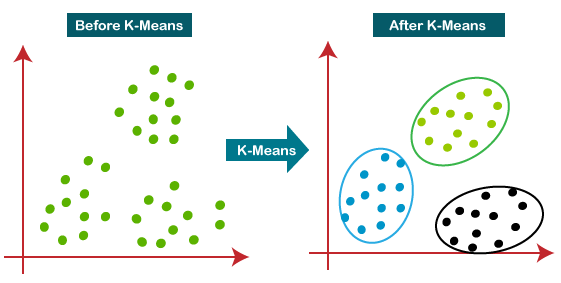
Notice that in the image on the right, the data points have been colored into 3 different groups that correspond well to those distinct groups we would pick out by eye. One algorithm that can accomplish this automatically is the K-Means algorithm for clustering. (Fig: Sharma 2021)

### How does the K-means method work?
The goal of K-means clustering is to partition $n$ observations (data points: $x_1$, $x_2$, ..., $x_n$) into $K$ groups such that each data point belongs to the cluster with the nearest mean or centroid $\mu_k$. The algorithm thus proceeds as follows:
1. Randomly choose initial cluster centroids $\mu_1$, $\mu_2$, ... , $\mu_K$.
2. Loop through every index $j$ and make the assignment $c(j) = {\rm arg}{\rm min}_i ||x_j - \mu_i||^2$. That is, assign the data point $x_j$ to cluster $c(j)$, the cluster for which $x_j$ has minimum distance to the cluster mean $\mu_{c(j)}$.
3. After this process, recalculate the means so for each $j$, we have
$$
\mu_j := \frac{\sum_{x_i \ {\rm in \ cluster} \ j} x_i }{n_{j}},
$$
where $n_j$ is the number of data points in cluster $j$.
4. Repeat steps 2 and 3 until no or very few data points change clusters.

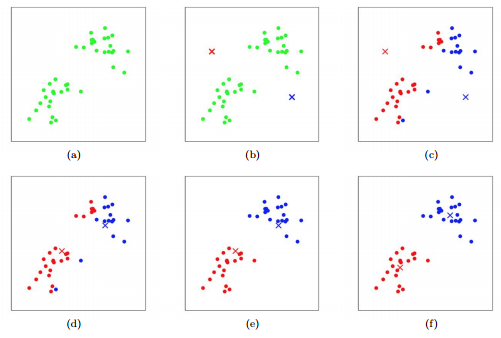

The above image demonstrates the steps of K-means. (a) Starting with a data set; (b) randomly assign two cluster centroids; (c) assign all data points to clusters based on proximity to centroids; (d) recompute centroids; (e) repeat data point assignment to centroids; (f) recompute centroids. (Fig: Ng & Jordan, Stanford)

### Applying KMeans to synthetic data
OK. Now to apply this method to some data sets using python. Let's start by loading the requisite packages. We'll actually start by making some artificial data (where we know we'll be able to obtain some nice clean clusters).

In [7]:
from sklearn.datasets import make_blobs

Using the makeblobs function we'll draw 200 samples that each have 2 features (dimensions) and come from 3 `blobs' (they are actually just normal distributions).

In [34]:
raw_data = make_blobs(n_samples = 200, n_features = 2, centers = 3, cluster_std = 1.5)
print(raw_data)

(array([[-4.62738792,  0.72424652],
       [ 7.9943153 ,  7.30951172],
       [-6.87939182, -0.24346544],
       [ 7.40250625, 10.32905058],
       [-5.93943843, -1.15027806],
       [ 4.4393782 ,  7.9247242 ],
       [-1.8231894 , -0.28654794],
       [ 6.38326563,  8.17805879],
       [-7.96507549, -1.82662392],
       [-5.0752438 , -3.14008716],
       [ 7.92423985, 10.36598704],
       [-0.23996271,  4.11671483],
       [ 7.85760705,  7.77094143],
       [-7.13465964, -0.6093707 ],
       [-5.94352085, -2.74513422],
       [-6.55574655, -2.05445515],
       [-1.51351252,  0.70189105],
       [ 6.98786969,  9.21094215],
       [-4.67129522, -0.89544534],
       [ 9.41561435,  9.09260424],
       [-9.04159044, -0.03498689],
       [-4.35824716,  1.15714736],
       [-8.44059635,  0.05415868],
       [-1.9879917 ,  4.1160171 ],
       [ 7.31695448, 10.92269118],
       [ 8.18255324,  9.63923528],
       [ 6.14156117,  8.24230796],
       [-3.77165599, -1.82041898],
       [ 7.538525  

By printing it, we can see its an object comprised of two arrays. One array contains 200 ordered pairs (our 200 data samples) and another array contains the actual `blob' from which each data point was drawn. In real data we would not have access to the latter, but it's nice here for us to be able to cross reference later and see how well K means might be able to recover these cluster identities.

Alright, now let's import the rest of our needed libraries. pandas for dataframe functionality; numpy for numerical computation tools; seaborn and matplotlib for plotting; we'll also make sure that plots appear inline.

In [26]:
import matplotlib.pyplot as plt

First, let's just plot the all the data to see if we can spot clusters by eye.

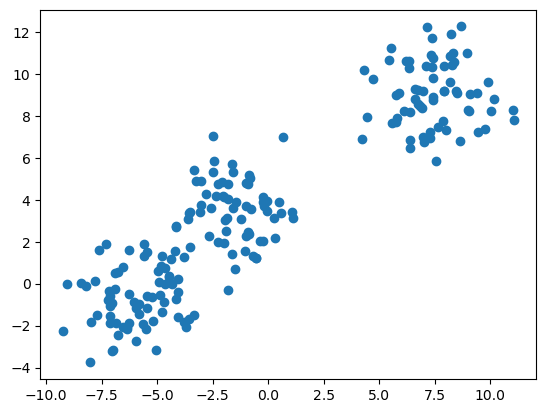

In [35]:
plt.scatter(raw_data[0][:,0], raw_data[0][:,1])

We (may) see 3 clearly separated clusters. NOTE: data is random; points and figure will be different every run. Let's color the points to see which `blobs' (normal distributions) they were actually drawn from.

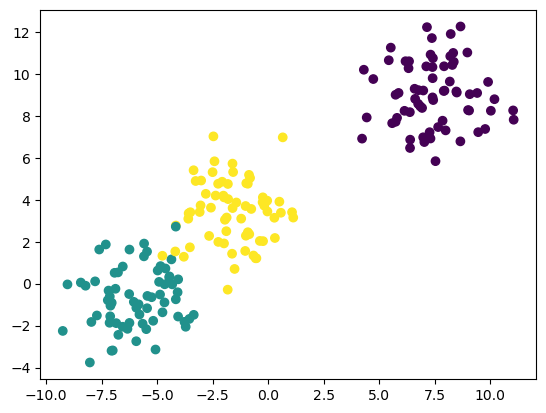

In [36]:
plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=raw_data[1])

Indeed each data point in a visually distinct cluster was drawn from a separate cluster. Now, let's assume we didn't know these cluster labels: Could K Means recover them via the algorithm we discussed above? To see this, let's build and train a clustering model. We'll start by importing the KMeans model from sklearn.

In [37]:
from sklearn.cluster import KMeans

Were we to have inspected the above data by eye, we might guess there are three clusters, so we can create an instance of the KMeans class with the cluster parameter set to 3.

In [50]:
model = KMeans(n_clusters=3, n_init = 'auto')

Now we'll invoke the model and pass the ordered pairs from raw_data.

In [51]:
model.fit(raw_data[0])

KMeans(n_clusters=3, n_init='auto')

## Making predictions with our clustering model
We can now predict which cluster each data point is from or identify the center of each cluster as a means of making sense of our data. The first of these can be done using the labels_ attribute of our model object:

In [40]:
model.labels_

array([1, 0, 1, 0, 1, 0, 2, 0, 1, 1, 0, 2, 0, 1, 1, 1, 2, 0, 1, 0, 1, 1,
       1, 2, 0, 0, 0, 1, 0, 2, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 2, 0, 1, 2, 0, 2, 2, 2, 0, 0, 2, 1, 1, 0, 1, 2, 2, 2, 2, 0,
       2, 1, 1, 1, 0, 2, 2, 0, 1, 0, 1, 1, 2, 2, 2, 2, 1, 0, 0, 0, 2, 0,
       0, 1, 1, 0, 0, 0, 2, 1, 2, 0, 1, 0, 2, 2, 0, 2, 0, 0, 2, 1, 1, 2,
       2, 1, 1, 1, 0, 2, 1, 1, 2, 1, 0, 2, 2, 2, 0, 0, 0, 0, 1, 0, 1, 0,
       2, 1, 0, 0, 1, 2, 0, 1, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 2, 2, 1, 0,
       0, 2, 1, 1, 2, 2, 2, 1, 2, 0, 1, 1, 2, 0, 1, 1, 0, 1, 1, 2, 1, 1,
       2, 2, 1, 2, 1, 0, 1, 0, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 0, 2,
       0, 0], dtype=int32)

See that the above is a collection of numbers either 0, 1, or 2 corresponding to the predicted cluster number of each data point.

Cluster centers are obtained using the cluster_centers_ attribute:

In [41]:
model.cluster_centers_

array([[ 7.45511882,  9.02733896],
       [-5.90341831, -0.68230387],
       [-1.5337211 ,  3.49423594]])

See that the above are just 3 ordered pairs corresponding to each clusters center in terms of each feature.

Since this is not a supervised learning algorithm, we need not cross-validate with the labeled data. Typically, we would not be applying clustering to labeled data. We can however plot the above results in terms of colored dots and 'X's to see what our clustering algorithm has decided in terms of point labeling. To do so, we will again perform a scatter plot with dots colored according to cluster identity, but now also add the 'X's for cluster centroid.

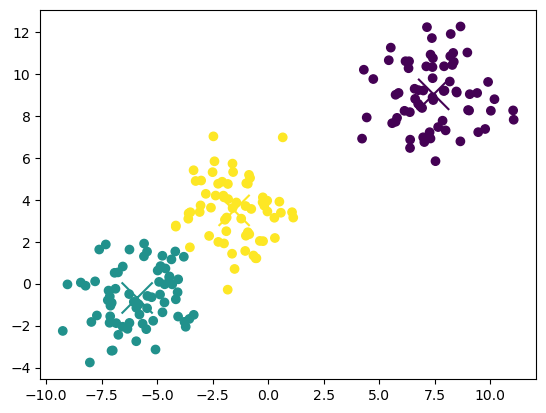

In [42]:
plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=model.labels_)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c=[0,1,2], marker='x', s=[500, 500, 500])

Now let's make the problem a bit harder by simply increasing the variance (to nine) and number (to five) of the normal distributions so they more likely overlap. In this case, it is unlikely we'll separate perfectly based on the blob of origin.

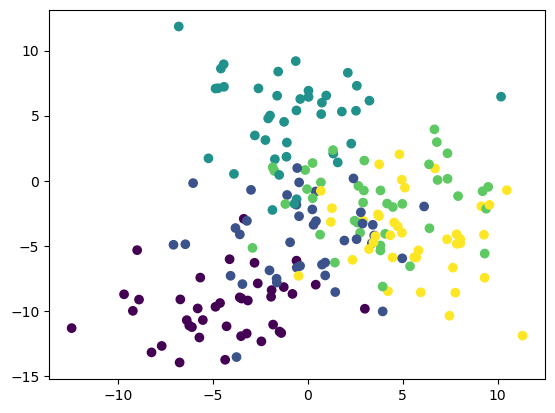

In [44]:
raw_data = make_blobs(n_samples = 200, n_features = 2, centers = 5, cluster_std = 3)
plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=raw_data[1])

While we've drawn from five blobs, even with color coding the blob of origin, we can see there's significant overlap. OK, now let's apply KMeans and try to pull out five clusters from this data.

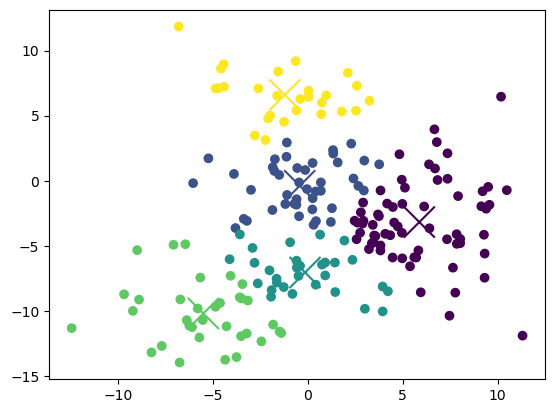

In [52]:
# generate an instance of the model with five clusters and fit to our existing data
model = KMeans(n_clusters=5, n_init = 'auto')
model.fit(raw_data[0])

# scatter plot with the Kmeans generated cluster labels and overlay x's for the cluster centroids.
plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=model.labels_)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c=[0,1,2,3,4], marker='x', s=[500, 500, 500, 500, 500])

We can see that Kmeans did not necessarily recover the blobs that generated the data but does cleanly separate the data into distinct groups in separate portions of the domain. However, if we look at this data, it seems like it would be sufficient to try and use fewer clusters. Maybe even two would do the job. Let's see what that looks like.

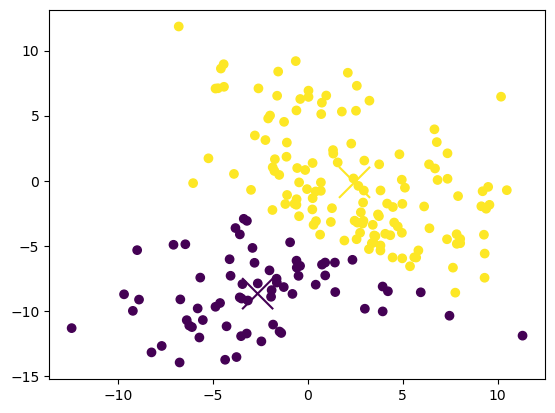

In [53]:
# generate an instance of the model with five clusters and fit to our existing data
model = KMeans(n_clusters=2, n_init = 'auto')
model.fit(raw_data[0])

# scatter plot with the Kmeans generated cluster labels and overlay x's for the cluster centroids.
plt.scatter(raw_data[0][:,0], raw_data[0][:,1], c=model.labels_)
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], c=[0,1], marker='x', s=[500, 500])

Indeed, that works pretty well. But how do we know how many clusters to use for our data? Will we always go off of this eyeball metric or is there something more systematic? Python actually has many ways of quantifying the quality of a cluster model generated from Kmeans. We'll just discuss a couple later.